In [33]:
# import the libraries I need

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# read the csv file and save it in a variable called df

df = pd.read_csv("diabetes.csv")

In [34]:
# print first 5 rows

df.head()

# check number of rows and columns

print(df.shape)

(768, 9)


In [35]:
# check data types and if there are missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [37]:
# columns that should never actually be zero

cols_with_fake_zeros = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

# loop through each column and count how many zeros it has

for col in cols_with_fake_zeros:
    zero_count = (df[col] == 0).sum()
    print(col,"->",zero_count,"zeros")

Glucose -> 5 zeros
BloodPressure -> 35 zeros
SkinThickness -> 227 zeros
Insulin -> 374 zeros
BMI -> 11 zeros


df["Insulin_was_missing"] = 

In [38]:
# create indicator columns before modifying any values

df["Insulin_was_missing"] = (df["Insulin"] == 0).astype(int)
df["SkinThickness_was_missing"] = (df["SkinThickness"] == 0).astype(int)

In [39]:
# impute zeros with group-wise median based on Outcome

df["Insulin"] = df.groupby("Outcome")["Insulin"].transform(
    lambda x: x.replace(0,x[x != 0].median())
)

In [40]:
# same imputation logic applied to SkinThickness

df["SkinThickness"] = df.groupby("Outcome")["SkinThickness"].transform(
     lambda x: x.replace(0,x[x != 0].median())
)

In [41]:
# only a small % of zeros in theses 3 columns, so simple median is enough

cols_to_fix = ["Glucose", "BloodPressure", "BMI"]

for col in cols_to_fix:
    median_value = df[col][df[col] !=0].median()
    df[col] = df[col].replace(0, median_value)
# check again to make sure no zeros left in these columns

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Insulin_was_missing,SkinThickness_was_missing
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.089844,141.753906,32.455208,0.471876,33.240885,0.348958,0.486979,0.295573
std,3.369578,30.438286,12.096642,8.890820,89.100847,6.875177,0.331329,11.760232,0.476951,0.500156,0.456597
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000,0.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000,0.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.300000,0.372500,29.000000,0.000000,0.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000,1.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000,1.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


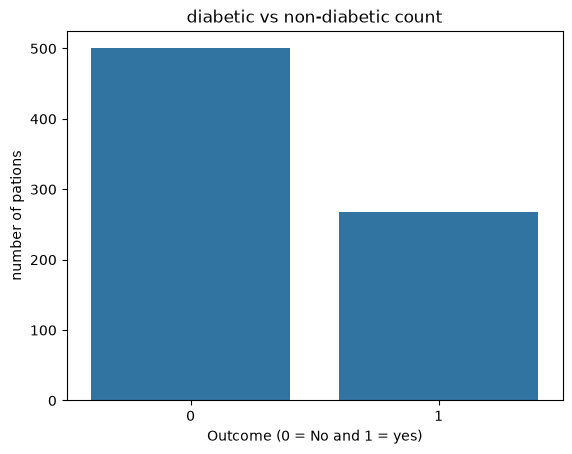

In [42]:
# check the target column distribution

print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize = True)*100)
# plot count of diabetic and non-diabetic

sns.countplot(x = "Outcome", data = df)
plt.title("diabetic vs non-diabetic count")
plt.xlabel("Outcome (0 = No and 1 = yes)")
plt.ylabel("number of pations")
plt.show()

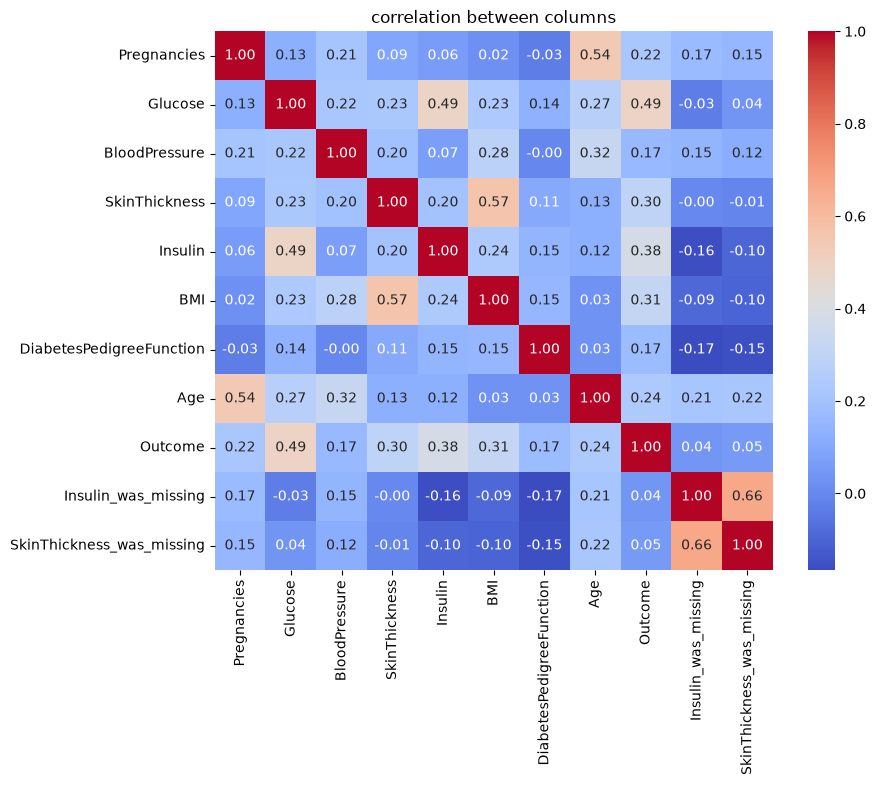

Outcome                      1.000000
Glucose                      0.492782
Insulin                      0.377081
BMI                          0.312038
SkinThickness                0.295138
Age                          0.238356
Pregnancies                  0.221898
DiabetesPedigreeFunction     0.173844
BloodPressure                0.165723
SkinThickness_was_missing    0.052603
Insulin_was_missing          0.040934
Name: Outcome, dtype: float64


In [43]:
# correlation matrix to see witch columns relate to Outcome

plt.figure(figsize = (9, 7))
cor = df.corr()
sns.heatmap(cor, annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("correlation between columns")
plt.show()

# sort columns by how strongly they relate to Outcome

print(cor["Outcome"].sort_values(ascending = False))

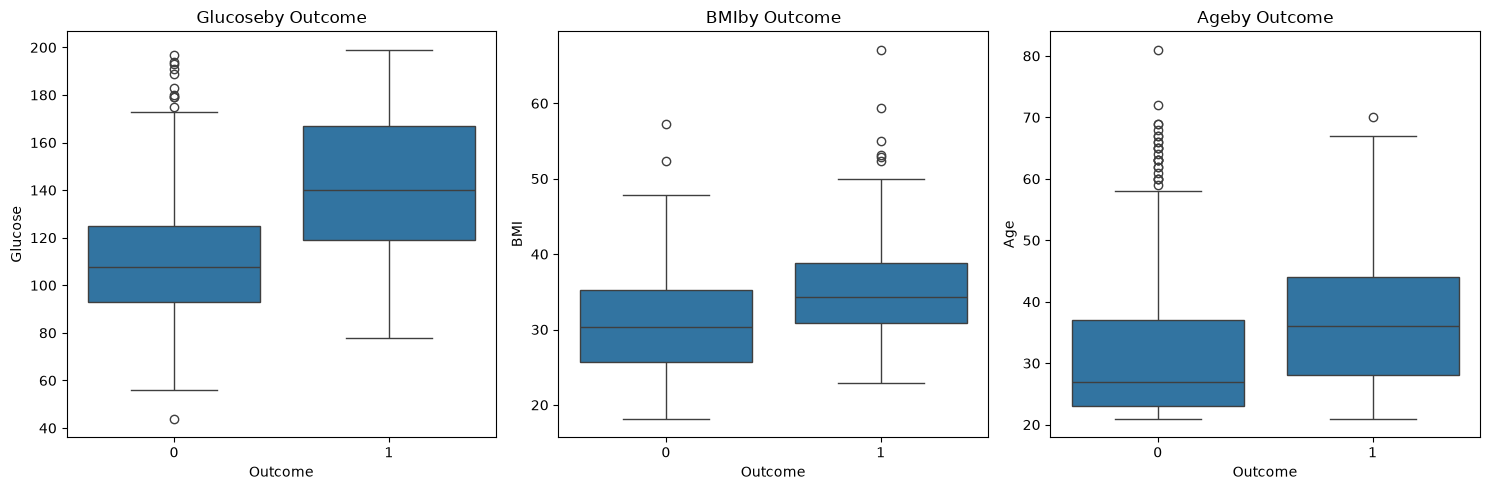

In [44]:
# compare Glucose, BMI and Age between diabetic and non-diabetic patients

features = ["Glucose", "BMI", "Age"]
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for i in range(len(features)):
    sns.boxplot(x = "Outcome", y = features[i], data = df, ax = axes[i])
    axes[i].set_title(features[i] + "by Outcome")
plt.tight_layout()
plt.show()


In [46]:
# import tools needed for splitting data and building first model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [47]:
# X is all the columns except Outcome 
# y is the Outcome column only

X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

X_train, X_test,y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Trsining set size:",X_train.shape)
print("Testing set size:", X_test.shape)


Trsining set size: (614, 10)
Testing set size: (154, 10)


In [49]:
# scale the feature so thay are all on a similar range

scaler = StandardScaler()

# fit the scaler on training data only , then transform training data

X_train_scaled = scaler.fit_transform(X_train)

# use the same scaler to transform test data

X_test_scaled = scaler.transform(X_test)
# creat and train the first simple model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# use the trained model to predict on test data

y_pred = model.predict(X_test_scaled)

In [50]:
# check how good the model is

print("accuracy:", accuracy_score(y_test, y_pred))
print()

print("comfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("classification report:")
print(classification_report(y_test, y_pred))





accuracy: 0.7922077922077922

comfusion matrix:
[[85 14]
 [18 37]]

classification report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        99
           1       0.73      0.67      0.70        55

    accuracy                           0.79       154
   macro avg       0.78      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154

